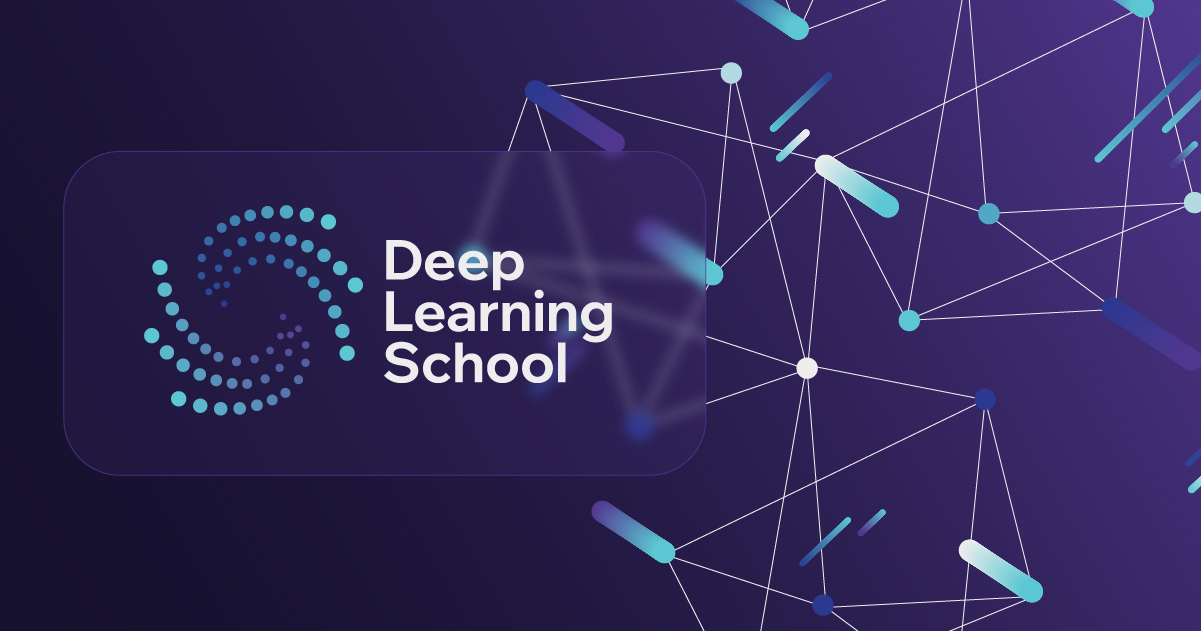

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

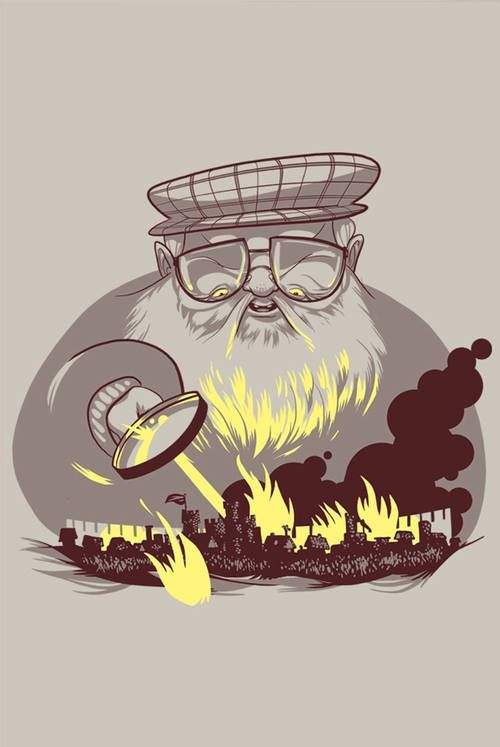

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.65$ --- 4 балла

3) $0.65 > score \geqslant 0.55$ --- 3 балла

4) $0.55 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.45$ --- 1 балл

6) $0.45 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 44.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 97.9MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [ ]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')
data.shape

(1557, 25)

**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

In [ ]:
skip_data=data.isna().sum()
skip_data[skip_data>0]

,0
title,840
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357
isAliveMother,1539
isAliveFather,1535


In [ ]:
data.drop(['mother', 'father', 'heir','spouse','isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'],axis=1,inplace=True)
#первые признаки не информативны а следующие плохо заполнены

In [ ]:
#просто посмотреть на названия категориальных и числовых
data_objects =data.select_dtypes(include=['object'])
data_int =data.select_dtypes(include=['int64','float64'])
print(data_objects.columns,'\n',data_int.columns)

Index(['name', 'title', 'culture', 'house'], dtype='object') 
 Index(['male', 'dateOfBirth', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity',
       'isAlive'],
      dtype='object')


In [ ]:
data.describe()

,male,dateOfBirth,book1,book2,book3,book4,book5,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
count,1557.000000,279.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,279.000000,1557.000000,1557.000000,1557.000000
mean,0.590880,247.551971,0.138728,0.327553,0.431599,0.562620,0.330122,0.128452,0.439306,35.290323,0.187540,0.062400,0.778420
std,0.491829,61.550441,0.345774,0.469472,0.495458,0.496223,0.470408,0.334700,0.496462,26.364864,1.114648,0.121416,0.415443
min,0.000000,-25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,241.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.013378,1.000000
50%,1.000000,272.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,24.000000,0.000000,0.023411,1.000000
75%,1.000000,286.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,49.000000,0.000000,0.063545,1.000000
max,1.000000,299.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,15.000000,1.000000,1.000000


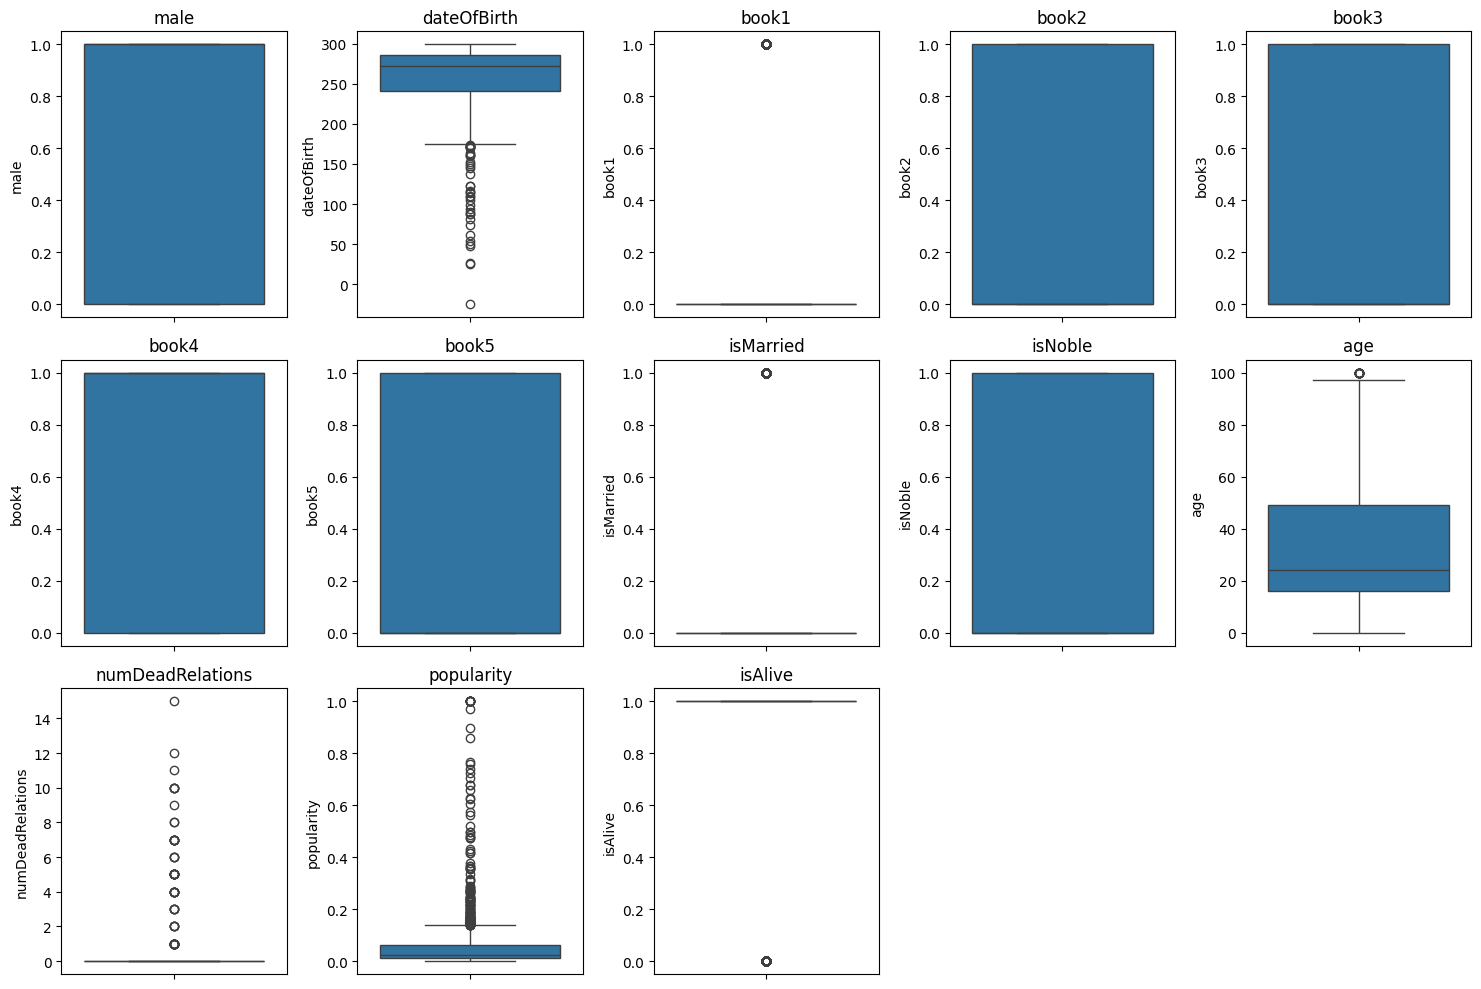

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

number_name = ['male', 'dateOfBirth', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity',
       'isAlive']

# Создаем графики
plt.figure(figsize=(15, 10))
for i in range(13):
    plt.subplot(3, 5, i+1)
    sns.boxplot(y=number_name[i], data=data)
    plt.title(number_name[i])

plt.tight_layout()  # улучшаем расположение графиков
plt.show()

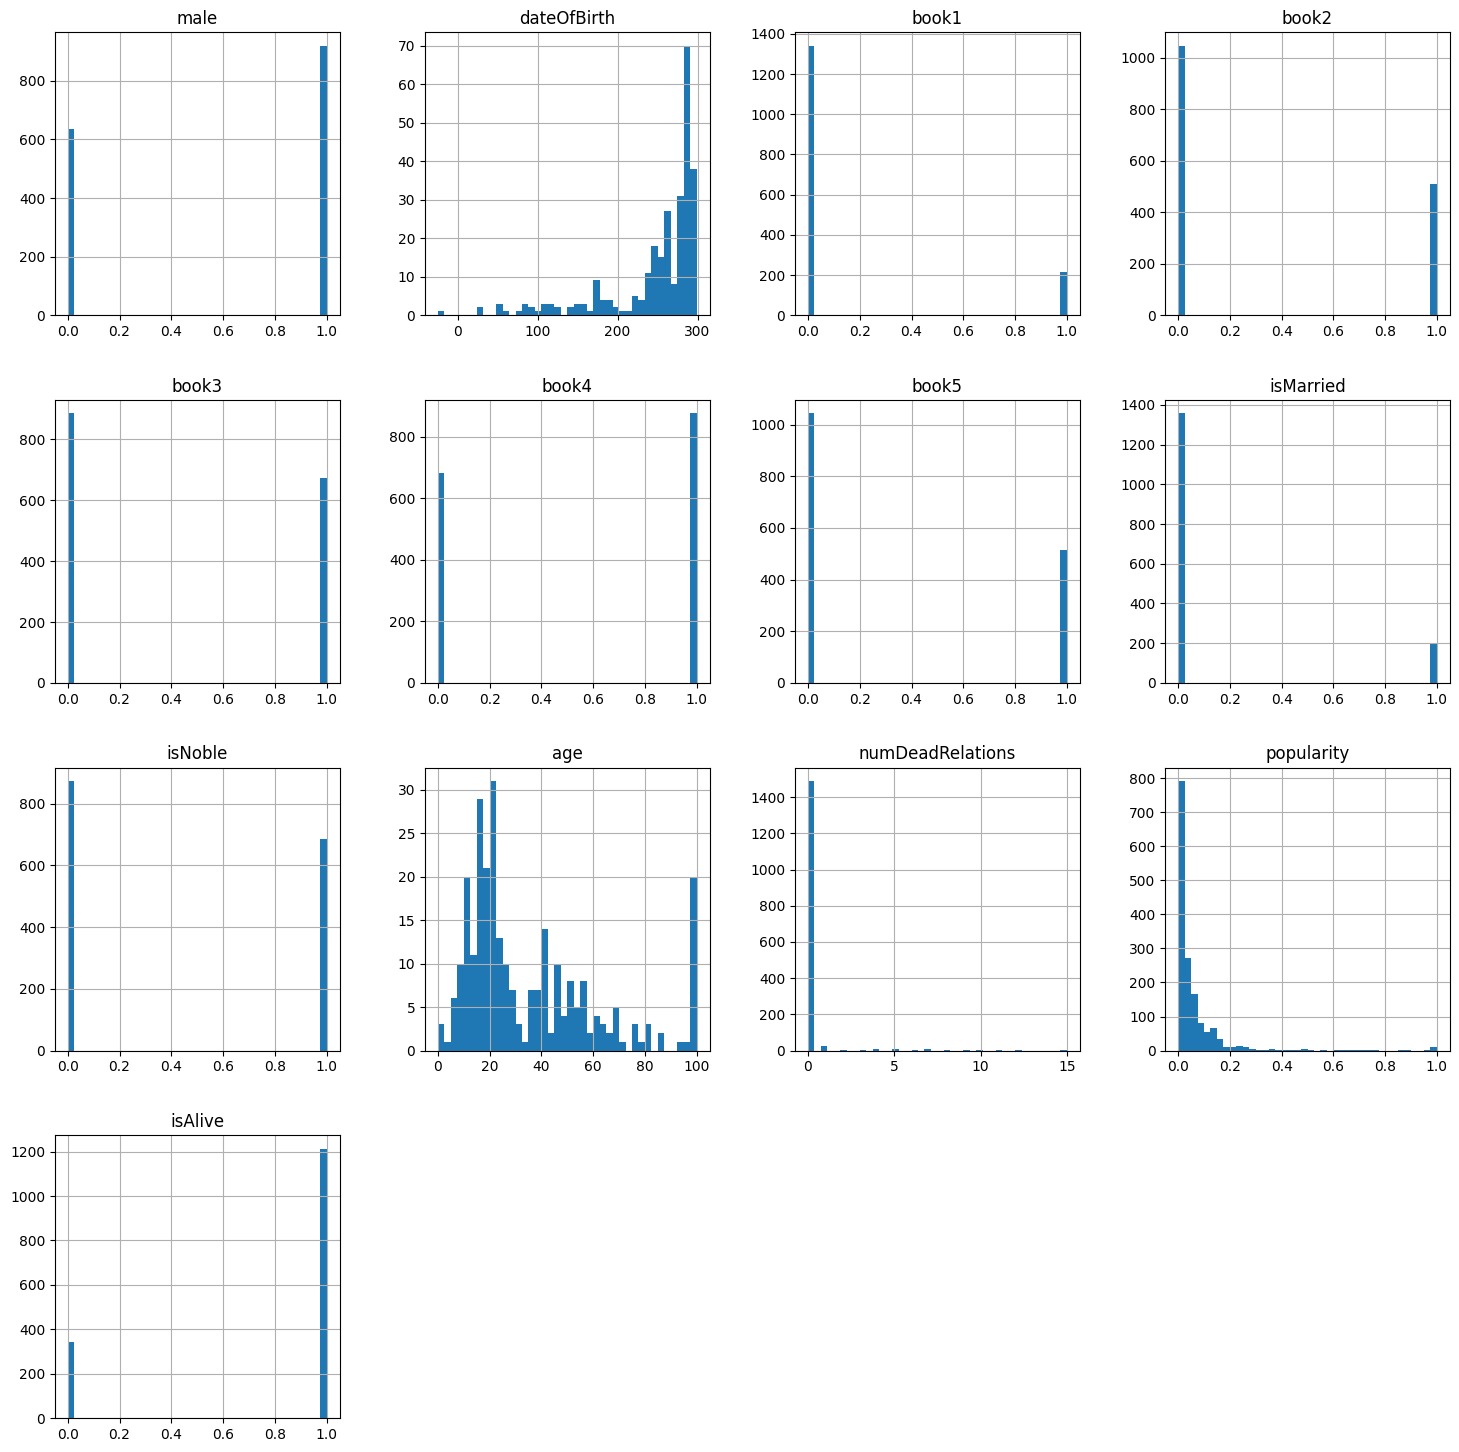

In [ ]:
data_int.hist(figsize=(18, 18), bins=40);

In [ ]:
#пока не мудрю с обработкой если скор будет маленький то попробую по другому
data.loc[:, ['culture', 'title', 'house']] = data[['culture','title','house']].fillna('Unknow')
data.loc[:, ['age', 'dateOfBirth']] = data[['age', 'dateOfBirth']].fillna(-1)

In [ ]:
skip_age=data[(data['dateOfBirth'].isna()) & (data['age'].isna())]
skip_age.shape

(0, 17)

**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [ ]:
#отталкиваюсь от медианы 50% персонажей будут популярными
tresh_popular=data['popularity'].median()
data['isPopular']=data['popularity'] >= tresh_popular

In [ ]:
data['boolDeadRelations']=data['numDeadRelations']>0

In [ ]:
# Подсказка
def culture(one_varian_of_cult):
  cult = {
      'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
      'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
      'Asshai': ["asshai'i", 'asshai'],
      'Lysene': ['lysene', 'lyseni'],
      'Andal': ['andal', 'andals'],
      'Braavosi': ['braavosi', 'braavos'],
      'Dornish': ['dornishmen', 'dorne', 'dornish'],
      'Myrish': ['myr', 'myrish', 'myrmen'],
      'Westermen': ['westermen', 'westerman', 'westerlands'],
      'Westerosi': ['westeros', 'westerosi'],
      'Stormlander': ['stormlands', 'stormlander'],
      'Norvoshi': ['norvos', 'norvoshi'],
      'Northmen': ['the north', 'northmen'],
      'Free Folk': ['wildling', 'first men', 'free folk'],
      'Qartheen': ['qartheen', 'qarth'],
      'Reach': ['the reach', 'reach', 'reachmen'],
  }
  for common_cult, varian_of_cult in cult.items():
          if one_varian_of_cult.lower() in varian_of_cult:
              return common_cult
  return one_varian_of_cult

data['culture'] = data['culture'].apply(culture)

In [ ]:
data.drop(columns=['popularity','numDeadRelations'], inplace = True)

In [ ]:
#признак вычисляет на основы данных с др жив ли еще персонаж. очень полезная фича
data['AgeBirthCheck'] = np.where(
    (data['age'] == -1) & (data['dateOfBirth'] == -1),
    -1,
    np.where(data['age'] + data['dateOfBirth'] == 305, 1, 0)
)

**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

In [ ]:
#не нужен пока что может быть потом можно будет достать дом оттуда
data.drop(columns=['name'],axis=1, inplace = True)

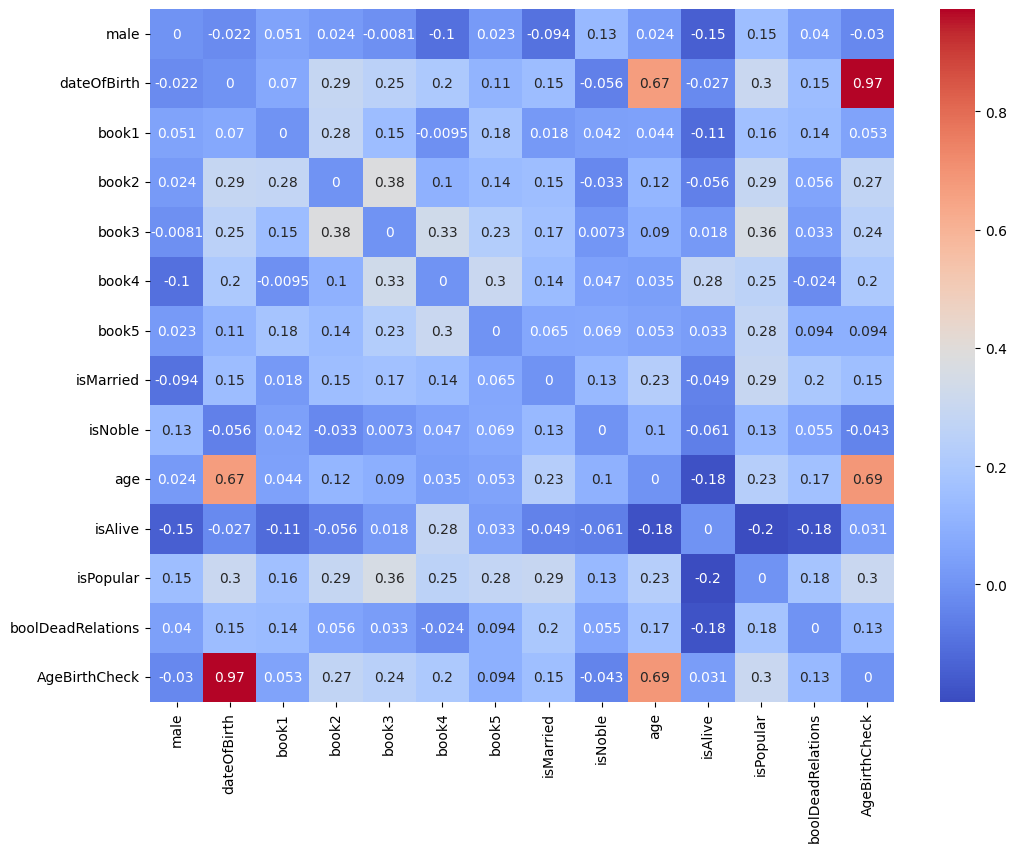

In [ ]:
matrix_corr = data._get_numeric_data().corr()
np.fill_diagonal(matrix_corr.values, 0)#чтобы диагональ не забивала глаз
plt.figure(figsize=(12, 9))
sns.heatmap(matrix_corr, cmap='coolwarm', annot=True);

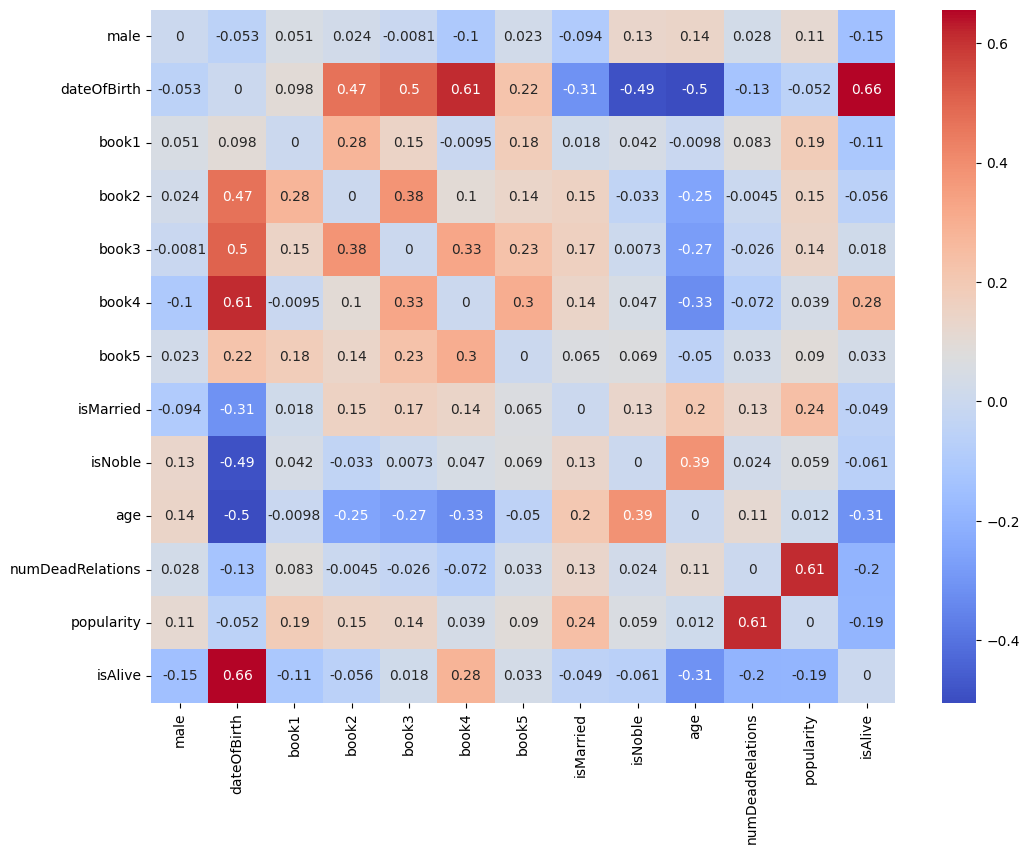

In [ ]:
data_check=pd.read_csv('game_of_thrones_train.csv', index_col='S.No')
data_check.drop(columns=['mother', 'father', 'heir','spouse','isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'],axis=1, inplace = True)
matrix_corr_check = data_check._get_numeric_data().corr()
np.fill_diagonal(matrix_corr_check.values, 0)
plt.figure(figsize=(12, 9))
sns.heatmap(matrix_corr_check, cmap='coolwarm', annot=True);
#видим что наши замены сильно покромсали корреляции
# но можем сделать вывод что год гождения важен для выживаемости

**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

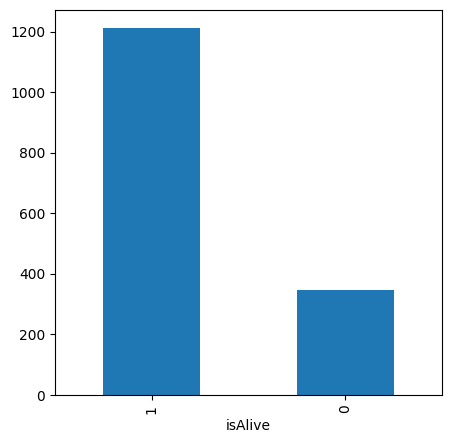

In [ ]:
data['isAlive'].value_counts().plot(kind='bar', figsize=(5, 5));
#видим несбалансированность но потом просто при разбиении учтем

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [ ]:
data.select_dtypes(include=['object']).columns

Index(['title', 'culture', 'house'], dtype='object')

In [ ]:
#слишком много уникальных значений
#создадим значение редкий нужно отметить что он вкладыва6т другой смысл в отличие от Unknow
popular_title=data['title'].value_counts().loc[lambda x: x > 10].index
data.loc[~data['title'].isin(popular_title), 'title'] = 'Rare'
data['title'].value_counts()

,count
title,
Unknow,840
Rare,311
Ser,306
Maester,29
Archmaester,21
Lord,19
Septon,16
Winterfell,15


In [ ]:
popular_title=data['culture'].value_counts().loc[lambda x: x > 12].index
data.loc[~data['culture'].isin(popular_title), 'culture'] = 'Rare'
data['culture'].value_counts()

,count
culture,
Unknow,1069
Northmen,103
Ironborn,91
Rare,87
Free Folk,56
Braavosi,40
Valyrian,28
Dornish,21
Ghiscari,18


In [ ]:
popular_title=data['house'].value_counts().loc[lambda x: x > 12].index
data.loc[~data['house'].isin(popular_title), 'house'] = 'Rare'
data['house'].value_counts()

,count
house,
Rare,769
Unknow,381
House Frey,89
Night's Watch,88
House Stark,56
House Targaryen,40
House Lannister,36
House Tyrell,33
House Greyjoy,30


In [ ]:
from sklearn.preprocessing import OneHotEncoder


encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cats = encoder.fit_transform(data.select_dtypes(include=['object']))

encoded_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(data.select_dtypes(include=['object']).columns))

number_data = data.select_dtypes(include=['number'])

number_data = number_data.reset_index(drop=True)# сбрасываем индексы чтобы не было расхождений
encoded_df = encoded_df.reset_index(drop=True)

data = pd.concat([number_data, encoded_df], axis=1)


In [ ]:
matrix_categorial=pd.concat([encoded_df,data['isAlive']], axis=1)

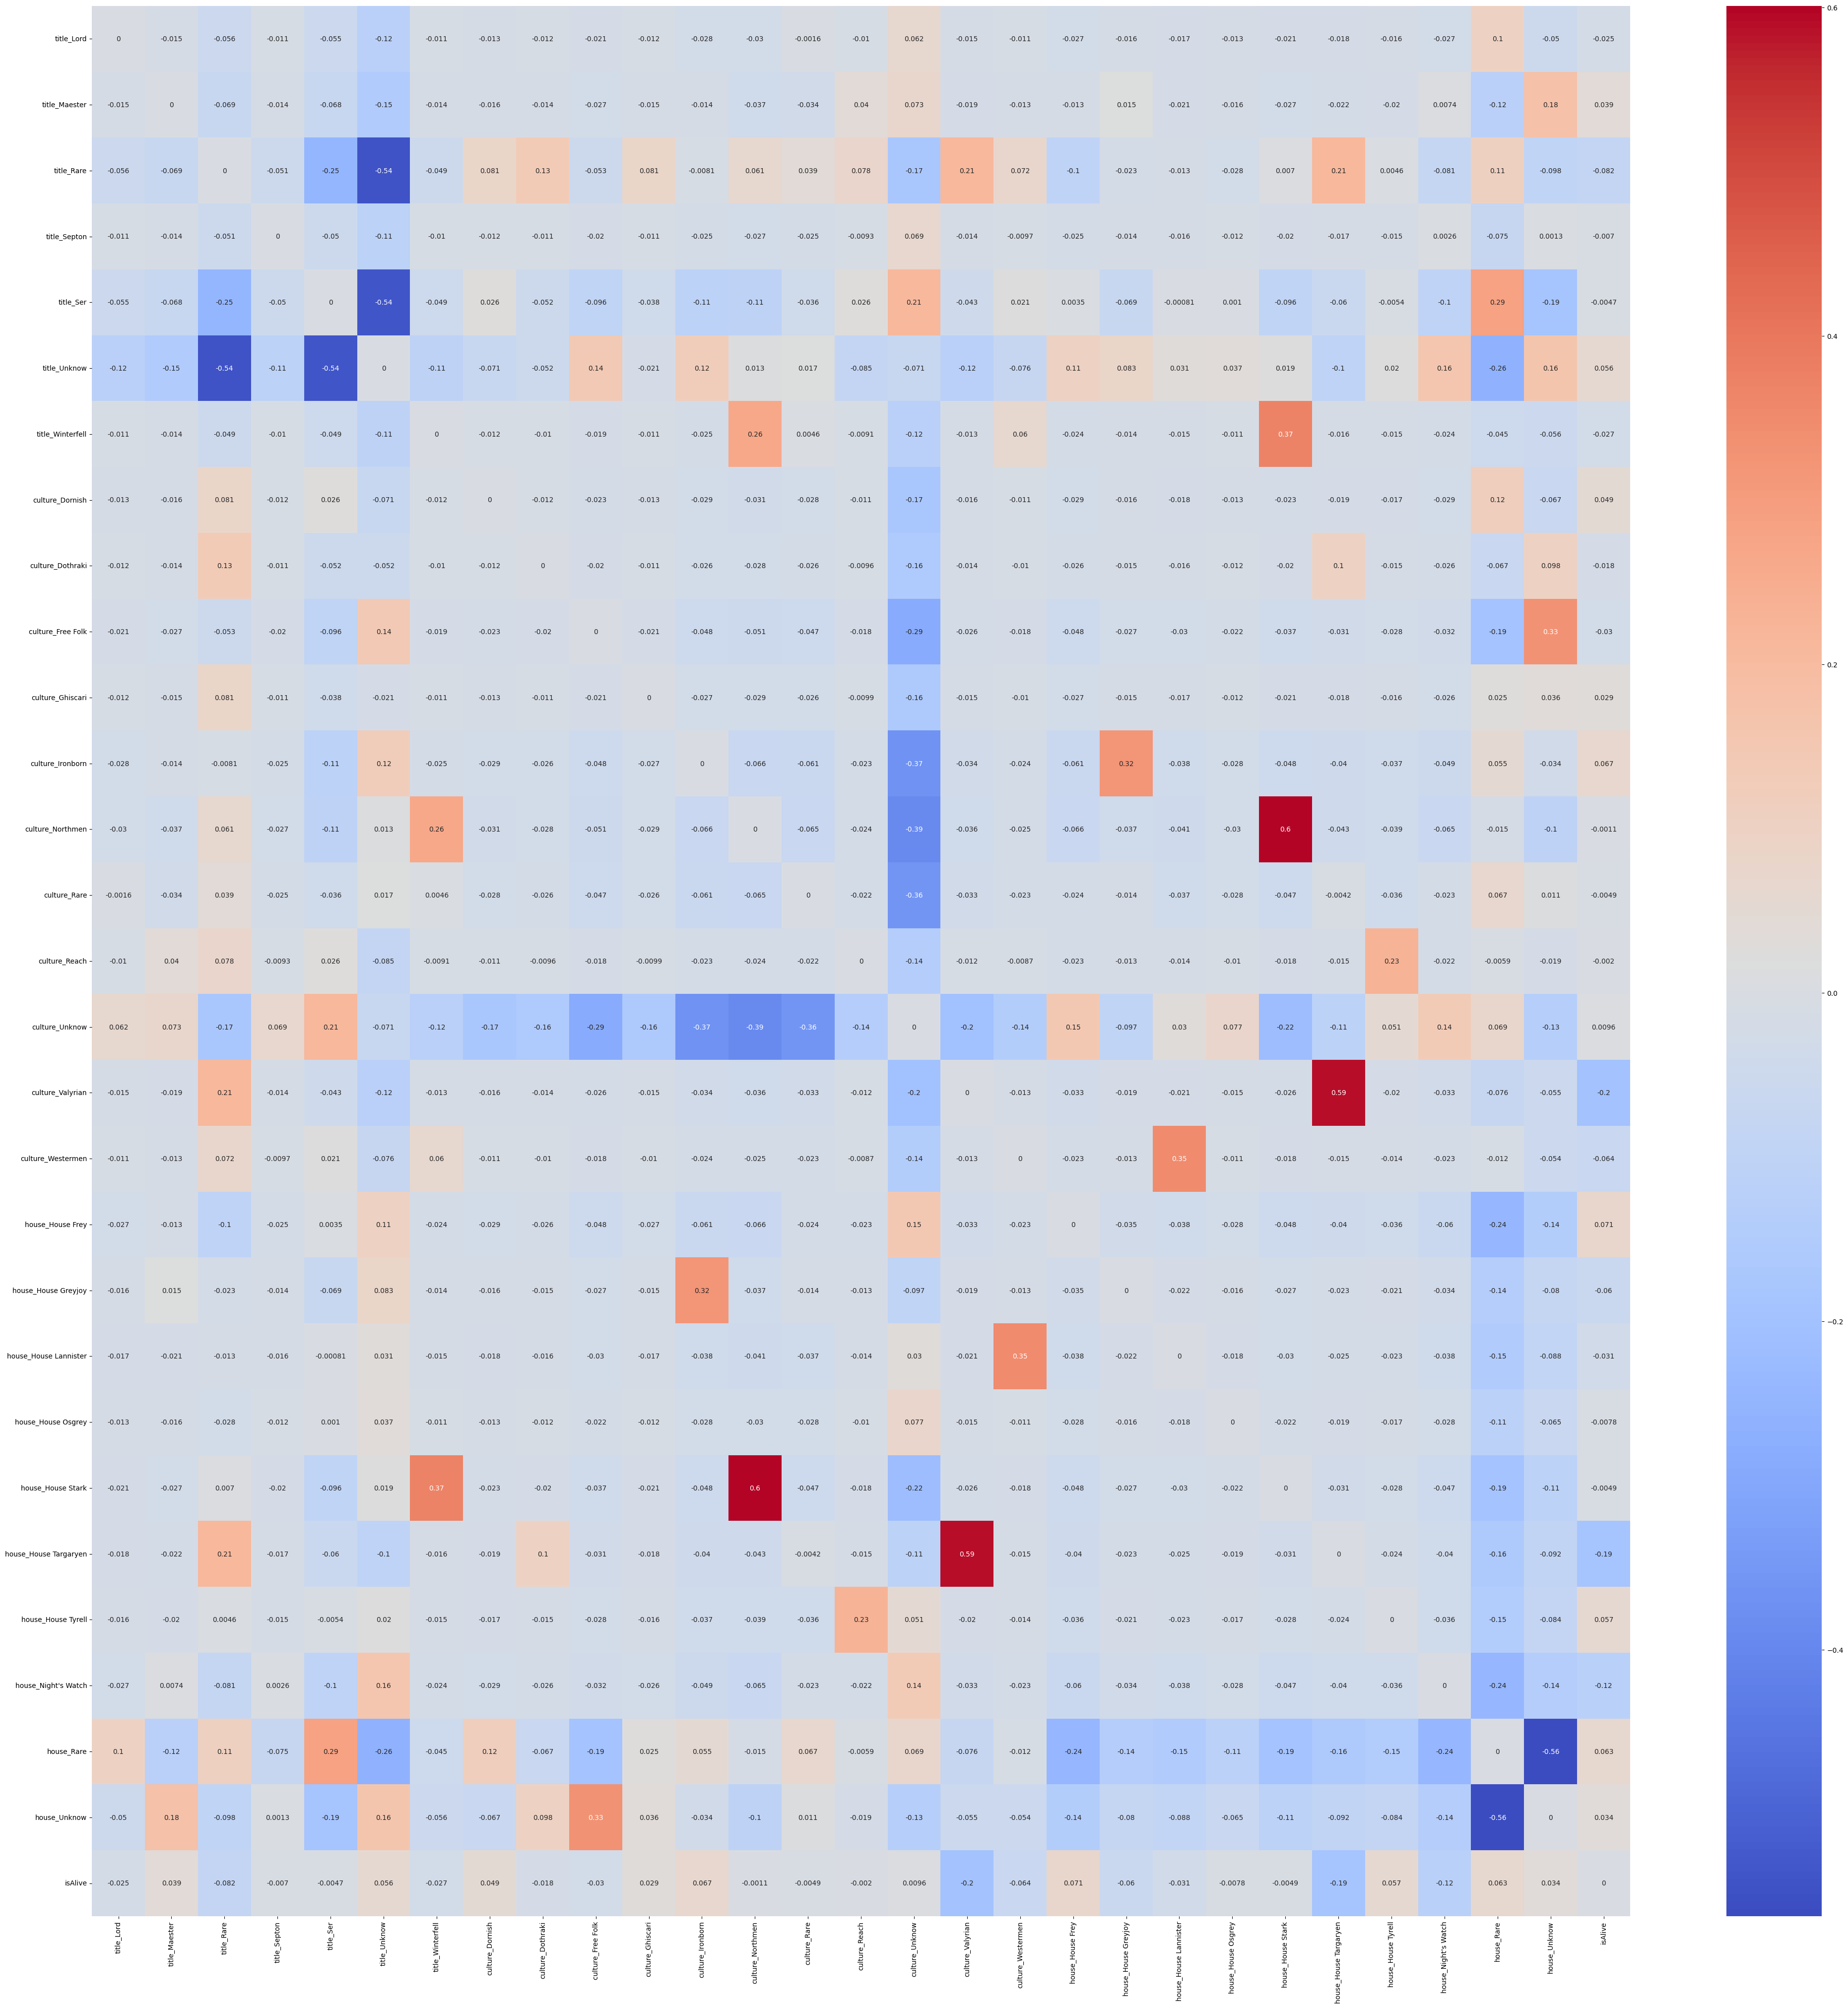

In [ ]:
matrix_corr_categorial = matrix_categorial._get_numeric_data().corr()
np.fill_diagonal(matrix_corr_categorial.values, 0)
plt.figure(figsize=(50, 50))
sns.heatmap(matrix_corr_categorial, cmap='coolwarm', annot=True);
#не вижу значимых кореляций к сожалению, но возможно в рассуждениях выше была ошибка

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

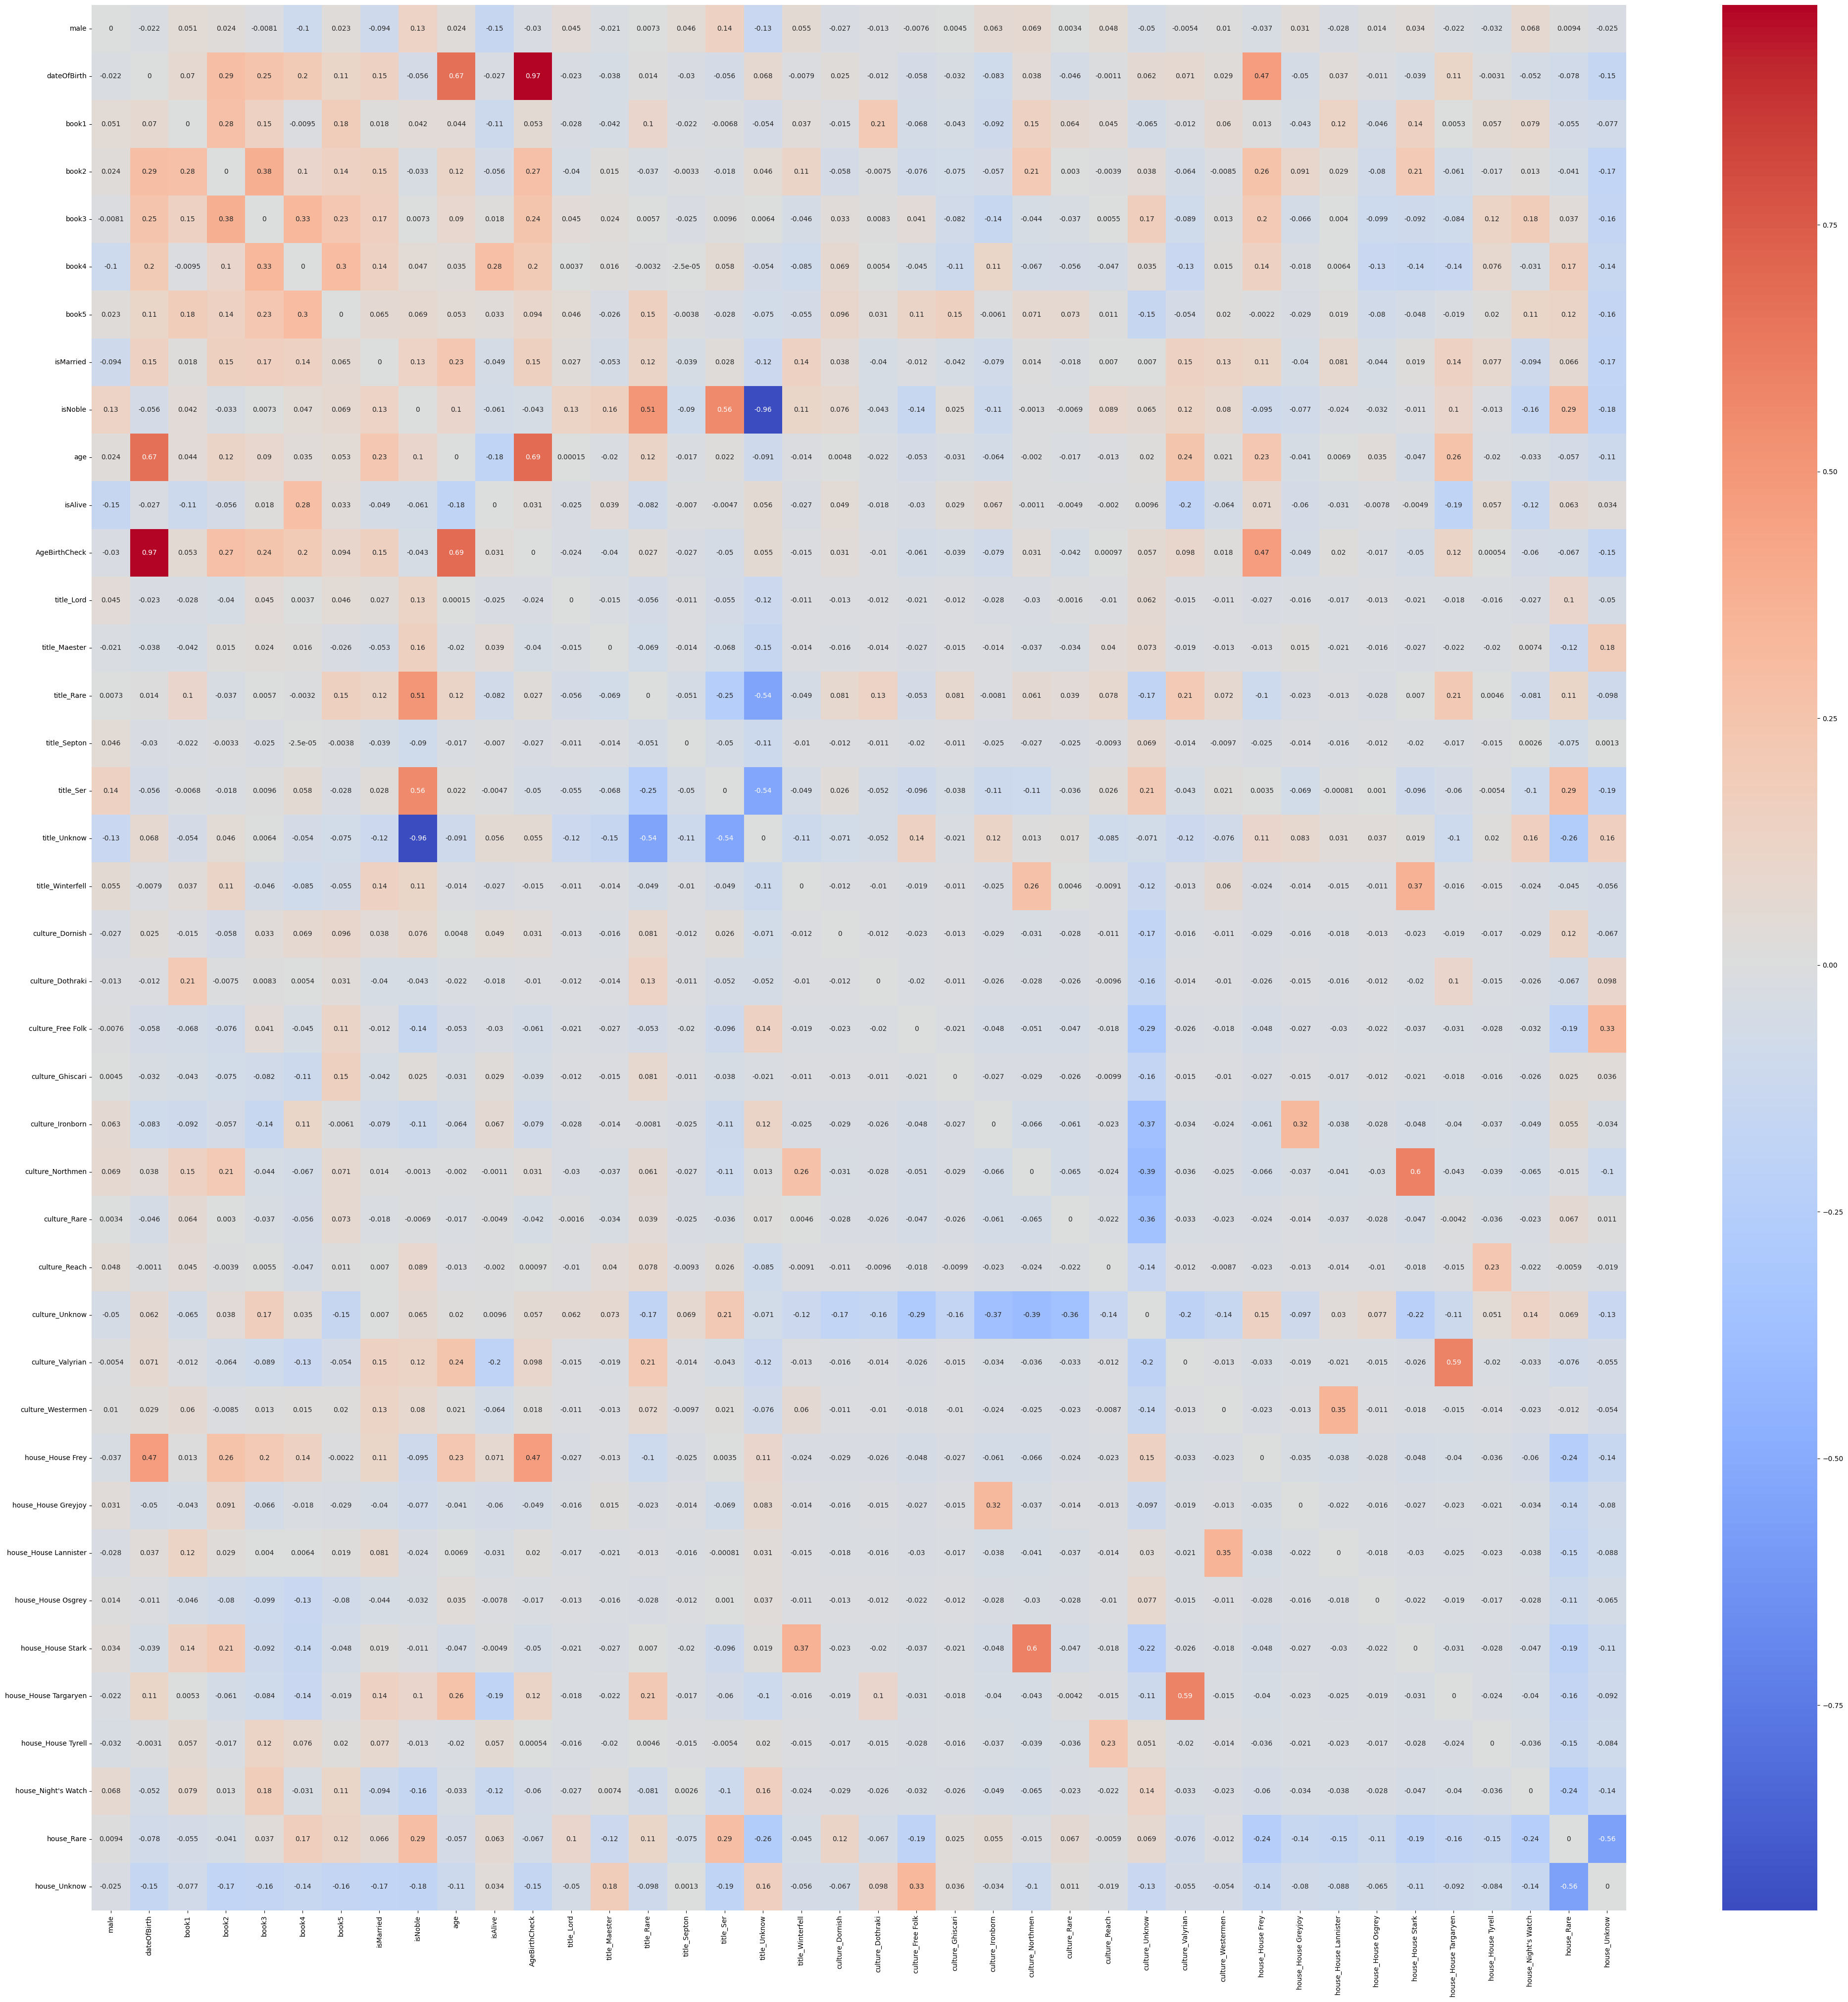

In [ ]:
matrix_corr_whole = data._get_numeric_data().corr()
np.fill_diagonal(matrix_corr_whole.values, 0)
plt.figure(figsize=(50, 50))
sns.heatmap(matrix_corr_whole, cmap='coolwarm', annot=True);

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [ ]:
y = data['isAlive']
X = data.drop(columns='isAlive')

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.2, stratify=y, random_state=17 )
#учитываем несбалансированность

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [ ]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

Аналогичным образом обучите остальные модели и сделайте предсказания на тестовой выборке.

In [ ]:
ada_boost = AdaBoostClassifier()
ada_boost.fit(X_train, y_train)
ada_pred = ada_boost.predict(X_test)

In [ ]:
gaussian_process = GaussianProcessClassifier()
gaussian_process.fit(X_train, y_train)
gpc_pred = gaussian_process.predict(X_test)

In [ ]:
gaussian_nb = GaussianNB()
gaussian_nb.fit(X_train, y_train)
gnb_pred = gaussian_nb.predict(X_test)

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [ ]:
svc = SVC()
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)

In [ ]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
dt_pred = decision_tree.predict(X_test)

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8269


Аналогичным образом посчитайте метрику accuracy для остальных моделей

In [ ]:
for clf in (ada_boost, gaussian_process, gaussian_nb, knn, svc, decision_tree):

    # Шаг 3. Предсказание на тестовых данных
    y_pred = clf.predict(X_test)

    # Шаг 4. Оценка предсказания по метрике accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(clf)
    print("Accuracy : %.4f" % accuracy)

AdaBoostClassifier()
Accuracy : 0.8429
GaussianProcessClassifier()
Accuracy : 0.8301
GaussianNB()
Accuracy : 0.7468
KNeighborsClassifier()
Accuracy : 0.8173
SVC()
Accuracy : 0.8237
DecisionTreeClassifier()
Accuracy : 0.8462


Тут я обрабатываю тестовый датасет по такому же принципу что и трейновый

In [ ]:
data_test = pd.read_csv('game_of_thrones_test.csv', index_col='S.No')
data_test.drop(['mother', 'father', 'heir','spouse','isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'],axis=1,inplace=True)
data_test.loc[:, ['culture', 'title', 'house']] = data_test[['culture','title','house']].fillna('Unknow')
data_test.loc[:, ['age', 'dateOfBirth']] = data_test[['age', 'dateOfBirth']].fillna(-1)
tresh_popular=data_test['popularity'].median()
data_test['isPopular']=data_test['popularity'] >= tresh_popular
data_test['boolDeadRelations']=data_test['numDeadRelations']>0

def culture(one_varian_of_cult):
  cult = {
      'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
      'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
      'Asshai': ["asshai'i", 'asshai'],
      'Lysene': ['lysene', 'lyseni'],
      'Andal': ['andal', 'andals'],
      'Braavosi': ['braavosi', 'braavos'],
      'Dornish': ['dornishmen', 'dorne', 'dornish'],
      'Myrish': ['myr', 'myrish', 'myrmen'],
      'Westermen': ['westermen', 'westerman', 'westerlands'],
      'Westerosi': ['westeros', 'westerosi'],
      'Stormlander': ['stormlands', 'stormlander'],
      'Norvoshi': ['norvos', 'norvoshi'],
      'Northmen': ['the north', 'northmen'],
      'Free Folk': ['wildling', 'first men', 'free folk'],
      'Qartheen': ['qartheen', 'qarth'],
      'Reach': ['the reach', 'reach', 'reachmen'],
  }
  for common_cult, varian_of_cult in cult.items():
          if one_varian_of_cult.lower() in varian_of_cult:
              return common_cult
  return one_varian_of_cult

data_test['culture'] = data_test['culture'].apply(culture)
data_test.drop(columns=['popularity','numDeadRelations'], inplace = True)
data_test['AgeBirthCheck'] = np.where(
    (data_test['age'] == -1) & (data_test['dateOfBirth'] == -1),
    -1,
    np.where(data_test['age'] + data_test['dateOfBirth'] == 305, 1, 0)
)
data_test.drop(columns=['name'],axis=1, inplace = True)
popular_title=data_test['title'].value_counts().loc[lambda x: x > 10].index
data_test.loc[~data_test['title'].isin(popular_title), 'title'] = 'Rare'

popular_title=data_test['culture'].value_counts().loc[lambda x: x > 12].index
data_test.loc[~data_test['culture'].isin(popular_title), 'culture'] = 'Rare'

popular_title=data_test['house'].value_counts().loc[lambda x: x > 12].index
data_test.loc[~data_test['house'].isin(popular_title), 'house'] = 'Rare'

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cats = encoder.fit_transform(data_test.select_dtypes(include=['object']))

encoded_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(data_test.select_dtypes(include=['object']).columns))

number_data = data_test.select_dtypes(include=['number'])

number_data = number_data.reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

data_test = pd.concat([number_data, encoded_df], axis=1)


In [ ]:
data_test = data_test.reindex(columns=X.columns, fill_value=0)#дозополняю отсутствующие колонки
data_test = scaler.transform(data_test)#масштабирую

In [ ]:
#выбрала его потому что попробовала с разными сидами и показал себя достаточно стабильно в зависимости от разных разбиений
final = ada_boost.predict(data_test)

Выберите лучшую модель.

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 10.6MB/s]


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
submission['isAlive']=final

Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
submission.to_csv("/content/new_submission.csv", index=False)